# Evalutaion of Image Quality of CNF vs. VAE

In [ ]:
!pip install umap-learn --no-deps torchdiffeq torchmetrics[image] torch-fidelity -q

In [24]:
import torch
import torch.optim as optim
import torch.nn as nn
import torchmetrics
import torch_fidelity
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary
from torchdiffeq import odeint
from torchmetrics.image.fid import FrechetInceptionDistance

import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import tensorflow as tf
import keras
from keras import layers, ops, Model, random, models

import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP
import re
import h5py

# if nvidia gpu available use it
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("Nb of Devices: ", torch.cuda.device_count())
    print("Device:",[torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
    print("Compute capability:", torch.cuda.get_device_capability(0))
    print("Supported archs:", torch.cuda.get_arch_list())

PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
Nb of Devices:  2
Device: ['Tesla T4', 'Tesla T4']
Compute capability: (7, 5)
Supported archs: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


## 1. Dataset Preperation

In [26]:
# Load Data
data_path_64 = "/kaggle/input/datasets/mikematician/galaxy/Galaxy10_DECals_64.h5"

with h5py.File(data_path_64, "r") as f:
    images = np.array(f["images"])   # shape (17736, 64, 64, 3)
    labels = np.array(f["ans"])      # shape (17736,)

# Print Shapes
print("Images shape:", images.shape)
print("Labels shape:", labels.shape, "dtype:", labels.dtype)

Images shape: (17736, 64, 64, 3)
Labels shape: (17736,) dtype: uint8


In [74]:
# normalize to [0, 1]
images = images / 255

In [27]:
# Class names from the Galaxy10 DECaLS documentation
class_names = {
    0: "Disturbed Galaxies",
    1: "Merging Galaxies",
    2: "Round Smooth Galaxies",
    3: "In-between Round Smooth Galaxies",
    4: "Cigar Shaped Smooth Galaxies",  
    5: "Barred Spiral Galaxies",
    6: "Unbarred Tight Spiral Galaxies",
    7: "Unbarred Loose Spiral Galaxies",
    8: "Edge-on Galaxies without Bulge",
    9: "Edge-on Galaxies with Bulge"
}

unique, counts = np.unique(labels, return_counts=True)
print("Class distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u} ({class_names[u]}): {c}")

Class distribution:
Class 0 (Disturbed Galaxies): 1081
Class 1 (Merging Galaxies): 1853
Class 2 (Round Smooth Galaxies): 2645
Class 3 (In-between Round Smooth Galaxies): 2027
Class 4 (Cigar Shaped Smooth Galaxies): 334
Class 5 (Barred Spiral Galaxies): 2043
Class 6 (Unbarred Tight Spiral Galaxies): 1829
Class 7 (Unbarred Loose Spiral Galaxies): 2628
Class 8 (Edge-on Galaxies without Bulge): 1423
Class 9 (Edge-on Galaxies with Bulge): 1873


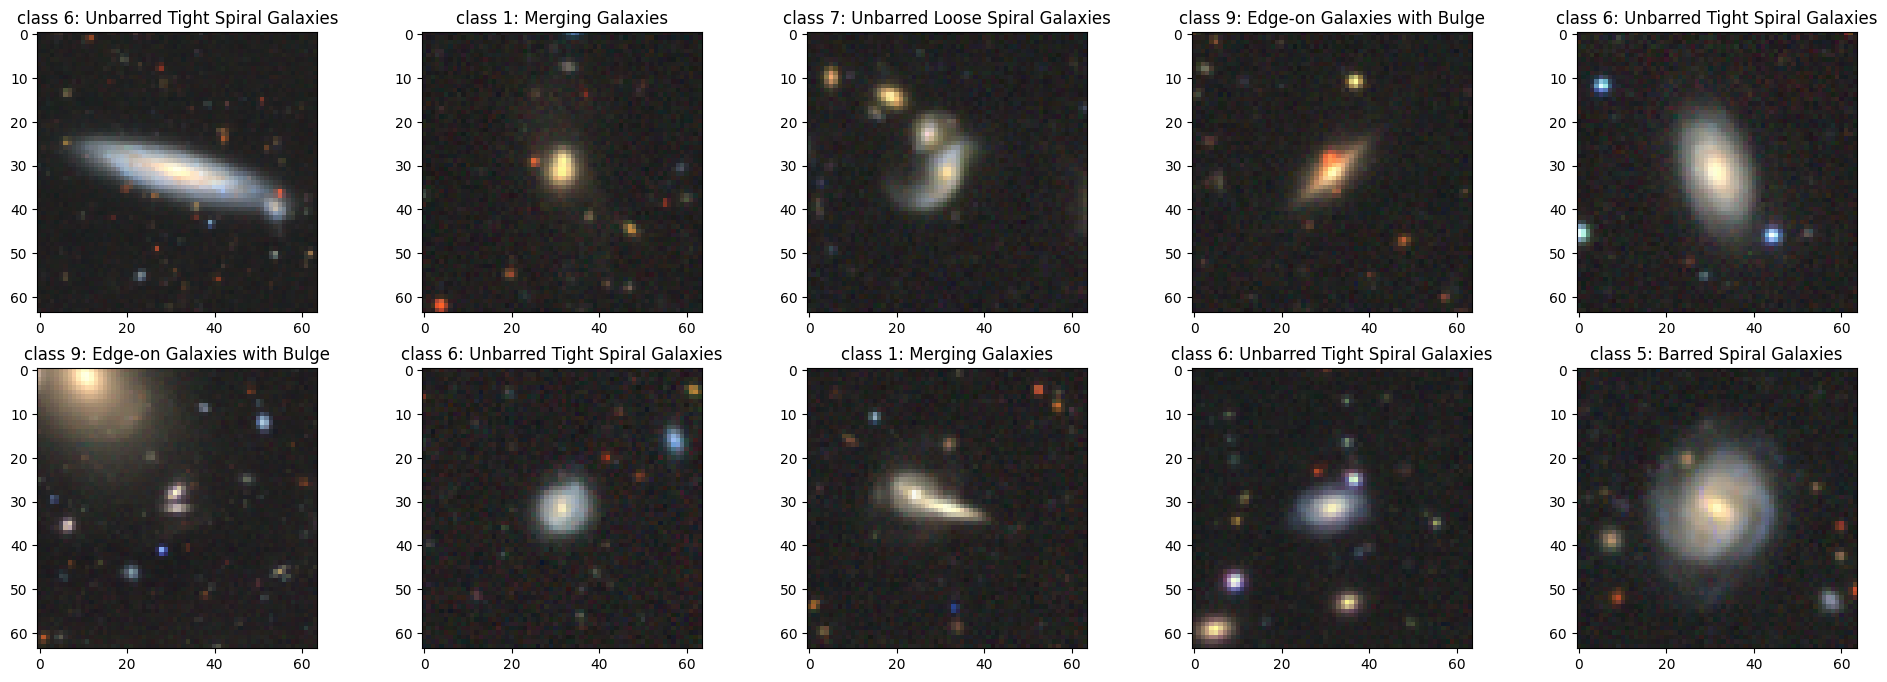

In [28]:
# Plot some Images
f, plane = plt.subplots(2, 5, figsize=(24, 8))
for row in plane:
    for axis in row:
        random_index = np.random.randint(0, len(labels))
        axis.imshow(images[random_index])
        axis.set_title(f"class {labels[random_index]}: {class_names[labels[random_index]]}")
plt.show()

## 2. Initialize and load models

### 2.1 CNF

In [29]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, groups=32):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, out_channels)
        self.conv1 = nn.Conv2d(in_channels+1, out_channels, 3, padding=1)
        self.norm2 = nn.GroupNorm(groups, out_channels)
        self.conv2 = nn.Conv2d(out_channels+1, out_channels, 3, padding=1)
        self.act   = nn.SiLU()
        self.skip = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def _tc(self, y, t):
        # concatenate t as extra channel
        return torch.cat([y, t.view(-1,1,1,1).expand(y.shape[0],1,y.shape[2],y.shape[3])], dim=1)

    def forward(self, t, y):
        h = self.act(self.norm1(self.conv1(self._tc(y, t))))
        h = self.act(self.norm2(self.conv2(self._tc(h, t))))
        return self.skip(y) + h


class Sampling(nn.Module):
    def __init__(self,  channels, kernelsize_sampling=None, kernelsize_conv=None, upscale=None, upsampling=False):
        super().__init__()
        if not upsampling:
            self.sampling = nn.AvgPool2d(kernel_size=kernelsize_sampling)
            self.conv = nn.Identity()
        else:
            self.sampling = nn.Upsample(scale_factor=upscale, mode="bilinear", align_corners=False)
            self.conv = nn.Conv2d(channels, channels, kernel_size=kernelsize_conv, padding=1)

    def forward(self, z):
        z = self.sampling(z)
        return self.conv(z)


class CNFResBlock(nn.Module):
    def __init__(self, channel, nb_filters, kernelsize):
        super().__init__()
        # ResNet layers
        self.resblock1 = ResBlock(channel, nb_filters)
        self.downsampling1 = Sampling(nb_filters, 2)
        self.resblock2 = ResBlock(nb_filters, 2*nb_filters)
        self.downsampling2 = Sampling(2*nb_filters, 2)
        self.resblock3 = ResBlock(2*nb_filters, 4*nb_filters)
        self.upsampling1 = Sampling(4*nb_filters, kernelsize_conv=kernelsize, upscale=2, upsampling=True)
        self.resblock4 = ResBlock(6*nb_filters, 2*nb_filters)
        self.upsampling2 = Sampling(2*nb_filters, kernelsize_conv=kernelsize, upscale=2, upsampling=True)
        self.resblock5 = ResBlock(3*nb_filters, nb_filters)
        self.outconv = nn.Conv2d(in_channels=nb_filters, out_channels=channel, kernel_size=kernelsize, stride=1, padding=1)

    def forward(self, t, xt):
        y = xt
        # ResNet
        dy_dt = self.resblock1(t, y)
        skip1 = dy_dt
        dy_dt = self.downsampling1(dy_dt)
            
        dy_dt = self.resblock2(t, dy_dt)
        skip2 = dy_dt
        dy_dt = self.downsampling2(dy_dt)
            
        dy_dt = self.resblock3(t, dy_dt)
        dy_dt = self.upsampling1(dy_dt)
        dy_dt = torch.cat([dy_dt, skip2], dim=1) 
            
        dy_dt = self.resblock4(t, dy_dt)
        dy_dt = self.upsampling2(dy_dt)
        dy_dt = torch.cat([dy_dt, skip1], dim=1) 

        dy_dt = self.resblock5(t, dy_dt)
        dy_dt = self.outconv(dy_dt)

        return dy_dt

In [30]:
# model parameters
data_channels = 3
start_channels = 64

# Initialize model
model = CNFResBlock(data_channels, start_channels, 3).to(device)

In [31]:
# load model
model.load_state_dict(torch.load("/kaggle/input/models/mikematician/u-net-cnf/pytorch/default/2/flowmatching_checkpoint_epoch50.pt", map_location=device))

<All keys matched successfully>

### 2.2 VAE

In [32]:
# Define Decoder
latent_dim = 128      # bigger = less stable training, smaller = few variation (too much info lost)
img_dim = (64, 64, 3)

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16 * 16 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((16, 16, 64))(x)

# first layer
x = layers.Conv2D(64, (3, 3), padding="same")(x)
x = layers.Activation("relu")(x)

# second decoder layer 16x16 --> 32x32
x = layers.Conv2D(64, (3, 3), strides=1, padding="same")(x)
x = layers.Activation("relu")(x)
x = layers.UpSampling2D((2, 2))(x)    # Known problem of artifacts when using Conv2DTranspose (overlapping regions)

# third decoder layer 32x32 --> 64x64
x = layers.Conv2D(128, (3, 3), strides=1, padding="same")(x)
x = layers.Activation("relu")(x)
x = layers.UpSampling2D((2, 2))(x)

# fourth decoder layer
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)

decoder_outputs = layers.Conv2D(3, (3, 3), padding="same", activation="sigmoid")(x)

VAE_decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

I0000 00:00:1782678263.287512      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13728 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782678263.293010      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [33]:
# load decoder weights
VAE_decoder.load_weights("/kaggle/input/models/mikematician/vae/keras/default/1/vae_decoder_epoch30.weights.h5")

## 3. Generate samples

In [34]:
nb_samples = 1000

# plot variables
rows = 8
nb_plots = rows * 4

### 3.1 CNF samples

In [35]:
# Sample Function
@torch.no_grad()
def sample_CNF(model, num_samples, t_0, t_end, ode_solver, device, rtol, atol, shape=(3, 64, 64)):
    model.eval()
    y_0 = torch.randn(num_samples, *shape, device=device)
    y = odeint(model, y_0, torch.tensor([t_0, t_end], dtype=torch.float32, device=device), rtol=rtol, atol=atol, method=ode_solver)
    y_0, y_1 = y[:,...]
    
    return y_1, y_0

In [36]:
t_0 = 0
t_1 = 1
ode_solver = "dopri5"
atol = 1e-7
rtol = 1e-7

generated_images_CNF , gaussian_noise_CNF = sample_CNF(model, nb_samples, t_0, t_1, ode_solver, device, rtol=rtol, atol=atol)

In [37]:
# convert to cpu
generated_images_CNF_cpu = generated_images_CNF.cpu()
gaussian_noise_CNF_cpu = gaussian_noise_CNF.cpu()

In [38]:
# free gpu memory
if device == "cuda":
    del generated_images_CNF
    del gaussian_noise_CNF
    torch.cuda.empty_cache()

In [39]:
# change dimensions for imshow
generated_images_CNF_cpu   = ((generated_images_CNF_cpu + 1.0) / 2.0).clamp(0, 1).permute(0, 2, 3, 1)
gaussian_noise_CNF_cpu = gaussian_noise_CNF_cpu.permute(0, 2, 3, 1)

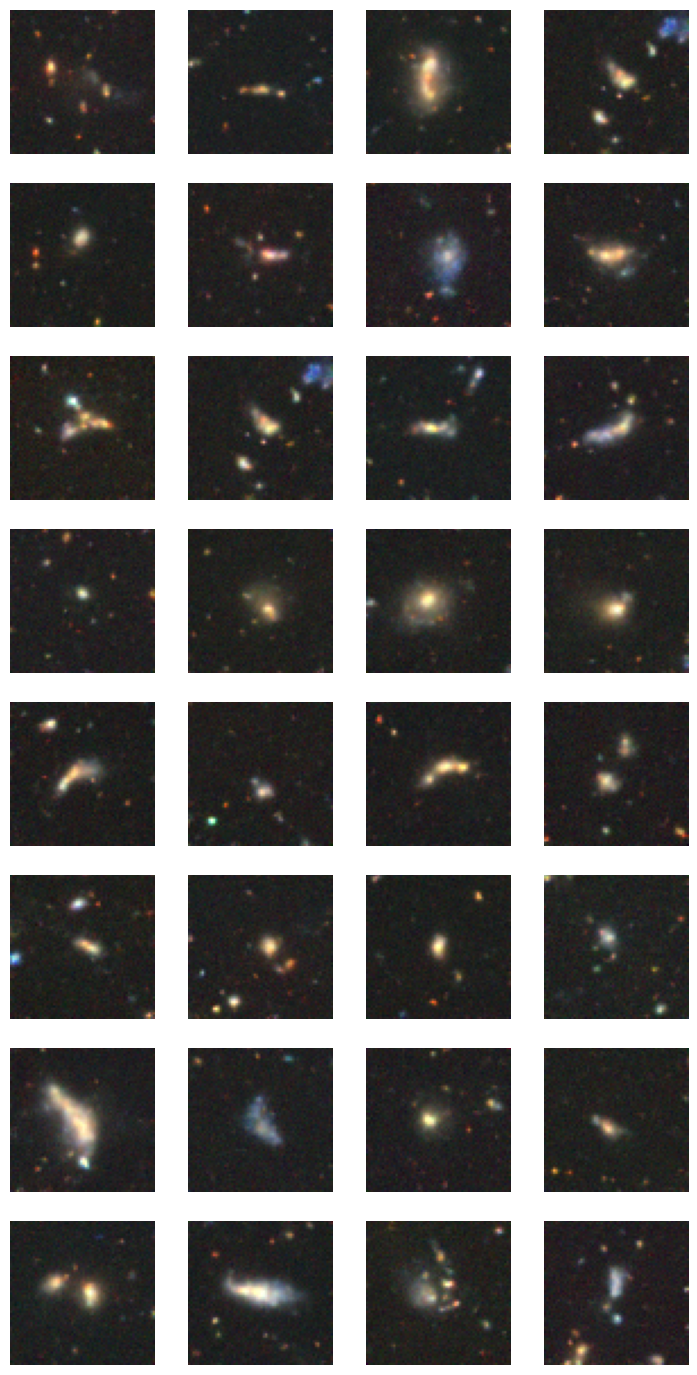

In [40]:
# plot example images
fig, ax = plt.subplots(rows, 4, figsize=(4 * 2.2, rows * 2.2))
ax = ax.flatten()
for i in range(0, nb_plots):
    random_nb = np.random.randint(nb_samples)
    ax[i].imshow(generated_images_CNF_cpu[random_nb].squeeze())
    ax[i].axis('off')

### 3.2 VAE samples

In [41]:
def sample_VAE(decoder, latent_dim, num_samples ):
    # Sample random points in the latent space
    z_random = np.random.normal(size=(num_samples, latent_dim))

    # Decode them into images
    generated = decoder.predict(z_random)

    return generated

In [42]:
generated_images_VAE = sample_VAE(VAE_decoder, latent_dim, nb_samples)

I0000 00:00:1782678720.908056     302 service.cc:152] XLA service 0x78c12c004710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782678720.908099     302 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782678720.908103     302 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782678721.037340     302 cuda_dnn.cc:529] Loaded cuDNN version 91002


23/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

I0000 00:00:1782678722.743931     302 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step


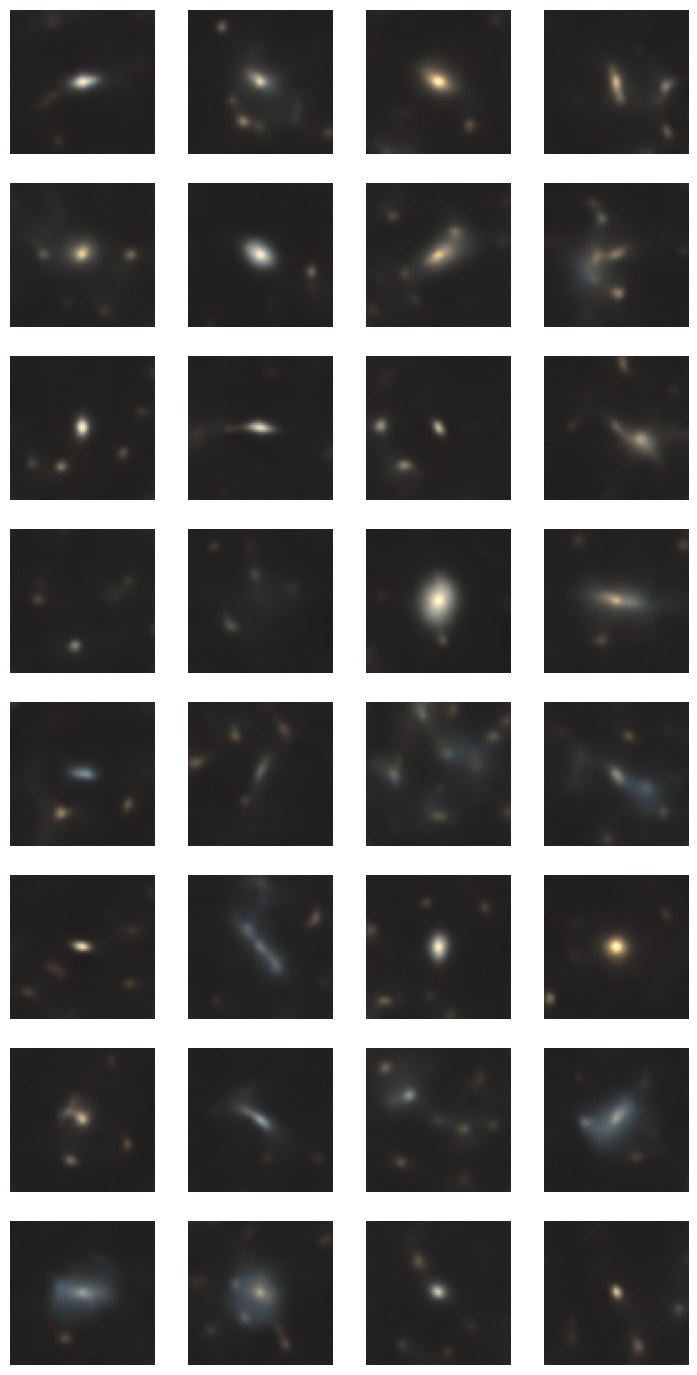

In [43]:
# Plot
fig, ax = plt.subplots(rows, 4, figsize=(4 * 2.2, rows * 2.2))
ax = ax.flatten()
for i in range(0, nb_plots):
    random_nb = np.random.randint(nb_samples)
    ax[i].imshow(generated_images_VAE[random_nb].squeeze())
    ax[i].axis('off')

## 4. Evaluation

In [75]:
# index for random sampeling real images 
indices = np.random.choice(images.shape[0], size=1000, replace=False)
real_samples = torch.from_numpy(images[indices]).permute(0, 3, 1, 2)
print(real_samples.shape)

torch.Size([1000, 3, 64, 64])


### 4.1 FID

In [76]:
# define FID function
def compute_fid(real, fake, device="cuda", batch_size=32):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    
    with torch.no_grad():
        for i in range(0, len(real), batch_size):
            fid.update(real[i:i+batch_size].to(device), real=True)
        for i in range(0, len(fake), batch_size):
            fid.update(fake[i:i+batch_size].to(device), real=False)
    
    return fid.compute().item()


In [77]:
# prepare images
vae_fid_images = torch.from_numpy(generated_images_VAE).permute(0, 3, 1, 2)
cnf_fid_images = generated_images_CNF_cpu.permute(0, 3, 1, 2)

# calculate FID
fid_cnf = compute_fid(real_samples, cnf_fid_images)
fid_vae = compute_fid(real_samples, vae_fid_images)

print(f"FID  CNF: {fid_cnf:.2f}   VAE: {fid_vae:.2f}")

FID  CNF: 55.66   VAE: 108.08


### 4.2 Power Spectrum

In [78]:
def radial_power_spectrum(images):
    if not isinstance(images, np.ndarray):
        images = images.detach().cpu().numpy()

    if images.ndim == 2:
        images = images[None, ...]
    height, width = images.shape[-2], images.shape[-1]

    # 2D-DFT
    DFT = np.fft.fftshift(np.fft.fft2(images), axes=(-2, -1))
    P = np.abs(DFT)**2
    P = P.mean(axis=0)
    P = P.mean(axis=0) 

    # radial mean
    radius_dict = {}
    for i in range(height):
        for j in range(width):
            kx = j - width // 2
            ky = i - height // 2
            k = int(round(np.sqrt(kx**2 + ky**2)))
            if k not in radius_dict:
                radius_dict[k] = np.array([P[i, j], 1.0])
            else:
                radius_dict[k] += np.array([P[i, j], 1.0])

    #sort k
    items = sorted(radius_dict.items())              
    ks    = np.array([k for k, _ in items])
    Pk    = np.array([v[0] / v[1] for _, v in items])
    return ks, Pk

In [79]:
# Original data Power Spectrum
real_power_spectrum = radial_power_spectrum(real_samples)

# CNF generated images Power Spectrum
CNF_power_spectrum = radial_power_spectrum(cnf_fid_images)
print(generated_images_CNF_cpu.shape)

# VAE generated images Power Spectrum
VAE_power_spectrum = radial_power_spectrum(vae_fid_images)

torch.Size([1000, 64, 64, 3])


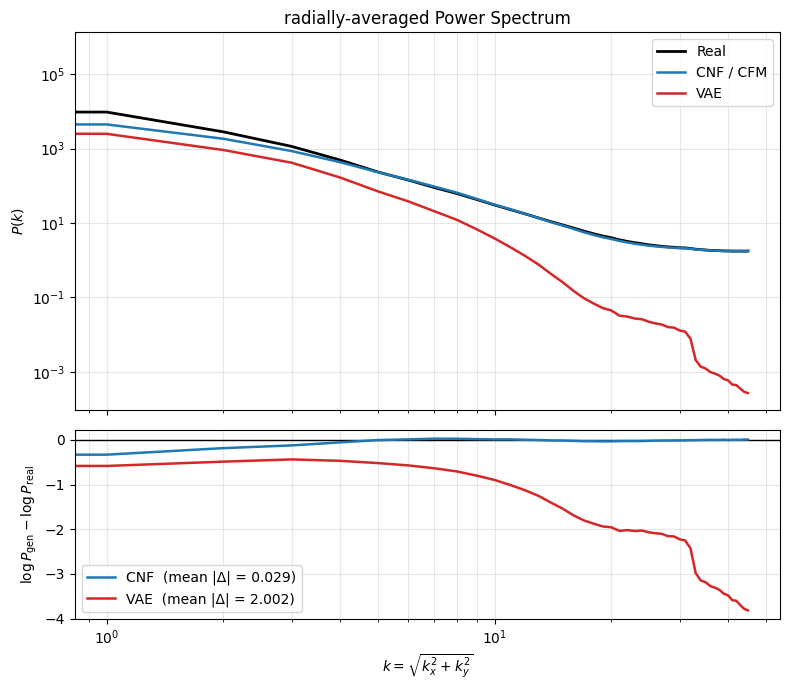

In [81]:
# plot power spectrum

k          = real_power_spectrum[0]
P_real     = real_power_spectrum[1]
P_cnf      = CNF_power_spectrum[1]
P_vae      = VAE_power_spectrum[1]

# helps reducing 0 in log
eps = 1e-12

# Log-difference
logdiff_cnf = np.log10(P_cnf + eps) - np.log10(P_real + eps)
logdiff_vae = np.log10(P_vae + eps) - np.log10(P_real + eps)

# scalar score (to compare both methods)
score_cnf = np.mean(np.abs(logdiff_cnf))
score_vae = np.mean(np.abs(logdiff_vae))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

# ax1: spectrum
ax1.loglog(k, P_real + eps, color="black", lw=2, label="Real")
ax1.loglog(k, P_cnf  + eps, color="C0", lw=1.8, label="CNF / CFM")
ax1.loglog(k, P_vae  + eps, color="C3", lw=1.8, label="VAE")
ax1.set_ylabel(r"$P(k)$")
ax1.set_title("radially-averaged Power Spectrum")
ax1.legend()
ax1.grid(True, which="both", alpha=0.3)

# ax2: log difference
ax2.axhline(0, color="black", lw=1)
ax2.plot(k, logdiff_cnf, color="C0", lw=1.8, label=f"CNF  (mean |Δ| = {score_cnf:.3f})")
ax2.plot(k, logdiff_vae, color="C3", lw=1.8, label=f"VAE  (mean |Δ| = {score_vae:.3f})")
ax2.set_xscale("log")
ax2.set_xlabel(r"$k = \sqrt{k_x^2 + k_y^2}$")
ax2.set_ylabel(r"$\log P_{\mathrm{gen}} - \log P_{\mathrm{real}}$")
ax2.legend()
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()